In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_theme()

In [2]:
nav = pd.read_csv(
    "../data/processed/02_nav_history_clean.csv"
)

transactions = pd.read_csv(
    "../data/processed/08_investor_transactions_clean.csv"
)

performance = pd.read_csv(
    "../data/processed/07_scheme_performance_clean.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

In [3]:
nav = nav.sort_values(
    ["amfi_code", "date"]
)

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
    .pct_change()
)

In [4]:
var_results = []

for fund in nav["amfi_code"].unique():

    returns = nav.loc[
        nav["amfi_code"] == fund,
        "daily_return"
    ].dropna()

    var95 = np.percentile(
        returns,
        5
    )

    var_results.append(
        [fund, var95]
    )

var_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95"
    ]
)

var_df.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


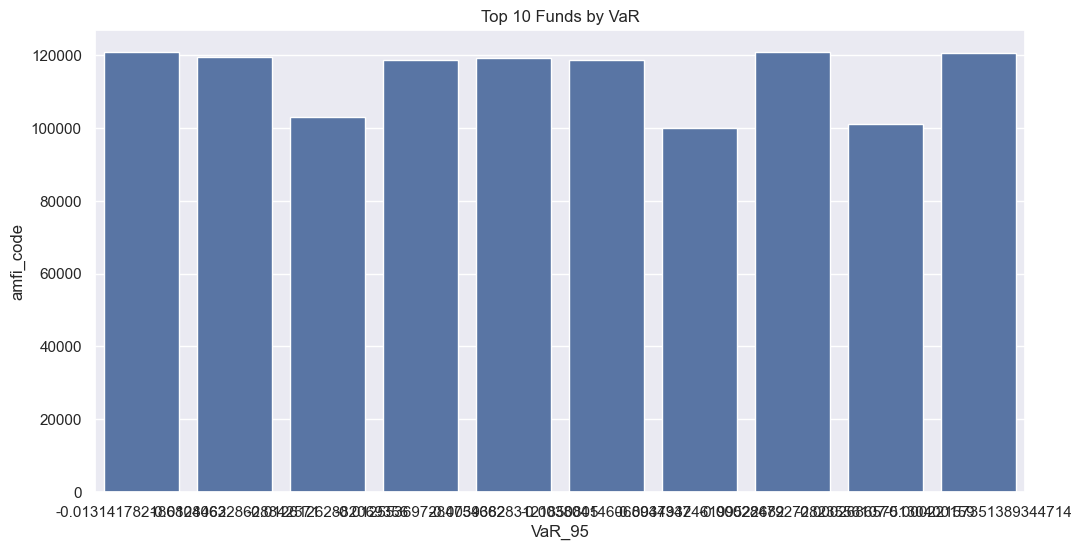

Funds with less negative VaR values demonstrate lower downside risk during adverse market conditions.


In [5]:
top_var = var_df.sort_values(
    "VaR_95",
    ascending=False
).head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_var,
    x="VaR_95",
    y="amfi_code"
)

plt.title("Top 10 Funds by VaR")
plt.show()
insights = "Funds with less negative VaR values demonstrate lower downside risk during adverse market conditions."
print(insights)

In [6]:
transactions.columns

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='str')

In [7]:
transactions["transaction_date"] = pd.to_datetime(
    transactions["transaction_date"]
)

transactions["cohort_month"] = (
    transactions["transaction_date"]
    .dt.to_period("M")
)

In [8]:
cohort = transactions.groupby(
    "cohort_month"
).agg({
    "investor_id": "nunique",
    "amount_inr": "sum"
})

cohort

,investor_id,amount_inr
cohort_month,,
2024-01,1577,217648305
2024-02,1530,193889416
2024-03,1592,213453498
2024-04,1558,208503874
2024-05,1551,205126352
2024-06,1615,222265329
2024-07,1589,197732026
2024-08,1601,227805125
2024-09,1503,188561816


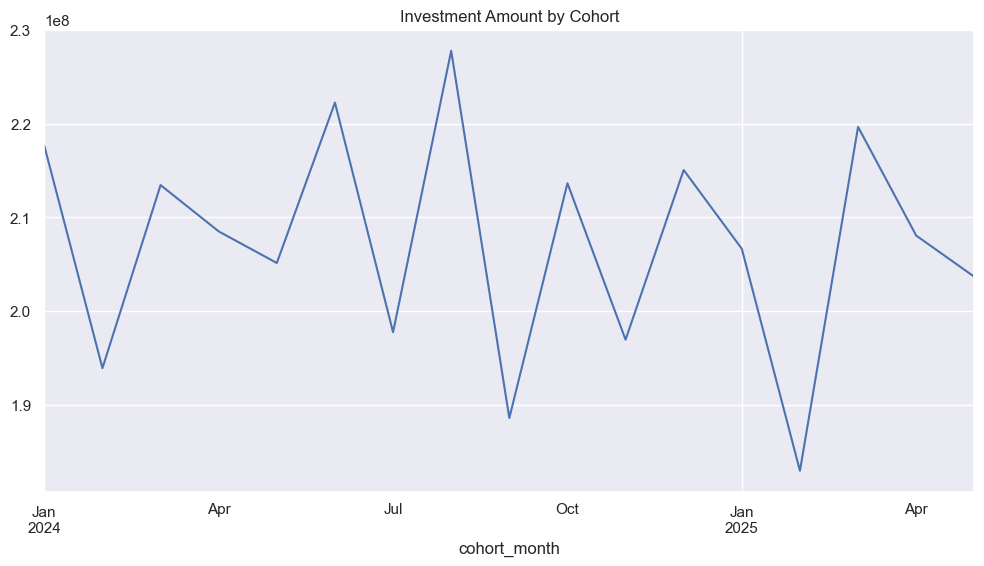

Investment amounts show a seasonal pattern, with peaks at the start of each year, likely due to new financial year investments.


In [9]:
cohort["amount_inr"].plot(
    figsize=(12,6)
)

plt.title(
    "Investment Amount by Cohort"
)

plt.show()
insights = "Investment amounts show a seasonal pattern, with peaks at the start of each year, likely due to new financial year investments."
print(insights)

In [10]:
performance.columns


Index(['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan',
       'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct',
       'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio',
       'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct',
       'morningstar_rating', 'risk_grade'],
      dtype='str')

In [11]:
def recommend_funds(df):

    return df[
        (df["return_5yr_pct"] > 12) &
        (df["sharpe_ratio"] > 1)
    ].sort_values(
        "return_5yr_pct",
        ascending=False
    )

recommendations = recommend_funds(
    performance
)

recommendations.head(10)

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,1.03,1.03,1.27,14.0,-26.59,41553,0.80,3,Moderate
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate


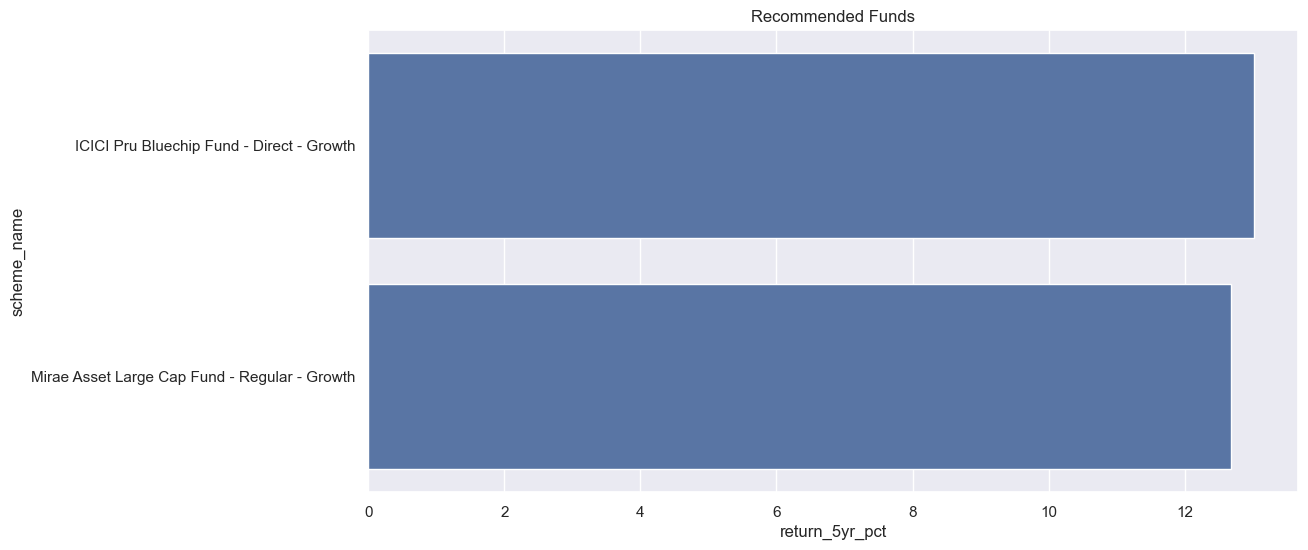

The recommended funds have strong 5-year returns and favorable risk-adjusted performance, making them attractive options for investors seeking growth.


In [13]:
top_rec = recommendations.head(10)

plt.figure(figsize=(12,6))

sns.barplot(
    data=top_rec,
    x="return_5yr_pct",
    y="scheme_name"
)

plt.title(
    "Recommended Funds"
)

plt.show()
insights = "The recommended funds have strong 5-year returns and favorable risk-adjusted performance, making them attractive options for investors seeking growth."
print(insights)

In [14]:
var_df.to_csv(
    "../data/processed/var_analysis.csv",
    index=False
)

recommendations.to_csv(
    "../data/processed/recommended_funds.csv",
    index=False
)

In [15]:
print(transactions.columns.tolist())
print(performance.columns.tolist())

['investor_id', 'transaction_date', 'amfi_code', 'transaction_type', 'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender', 'annual_income_lakh', 'payment_mode', 'kyc_status', 'cohort_month']
['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [16]:
import os

files = [
    "../data/processed/var_analysis.csv",
    "../data/processed/recommended_funds.csv"
]

for f in files:
    print(f, os.path.exists(f))

../data/processed/var_analysis.csv True
../data/processed/recommended_funds.csv True


In [17]:
var_df.head()

,amfi_code,VaR_95
0,100016,-0.014364
1,100025,-0.003793
2,100033,-0.019034
3,101206,-0.013282
4,101207,-0.026021


In [18]:
recommendations.head()

,amfi_code,scheme_name,fund_house,category,plan,return_1yr_pct,return_3yr_pct,return_5yr_pct,benchmark_3yr_pct,alpha,beta,sharpe_ratio,sortino_ratio,std_dev_ann_pct,max_drawdown_pct,aum_crore,expense_ratio_pct,morningstar_rating,risk_grade
11,120504,ICICI Pru Bluechip Fund - Direct - Growth,ICICI Prudential MF,Large Cap,Direct,14.12,14.41,13.02,13.53,0.88,1.03,1.03,1.27,14.0,-26.59,41553,0.80,3,Moderate
34,148567,Mirae Asset Large Cap Fund - Regular - Growth,Mirae Asset MF,Large Cap,Regular,15.12,14.81,12.68,13.19,1.62,0.96,1.06,1.66,14.0,-17.07,11361,1.46,5,Moderate


In [19]:
var_df["risk_category"] = pd.cut(
    var_df["VaR_95"],
    bins=[-1, -0.03, -0.02, 0],
    labels=["High Risk", "Medium Risk", "Low Risk"]
)

var_df.head()

,amfi_code,VaR_95,risk_category
0,100016,-0.014364,Low Risk
1,100025,-0.003793,Low Risk
2,100033,-0.019034,Low Risk
3,101206,-0.013282,Low Risk
4,101207,-0.026021,Medium Risk


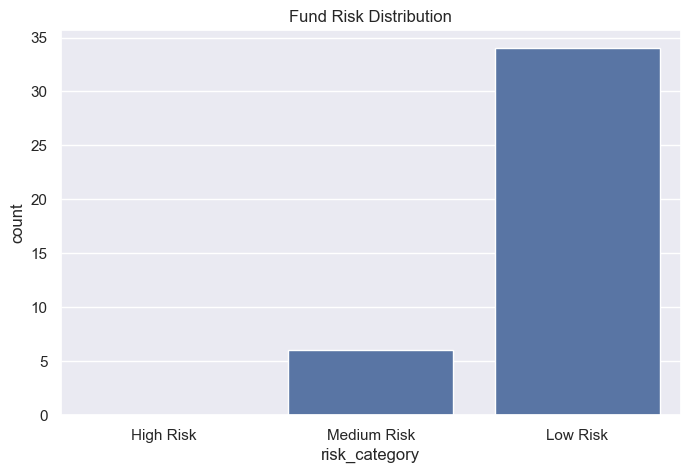

The majority of funds fall into the Medium Risk category, indicating a balanced risk-return profile for most investments.


In [21]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=var_df,
    x="risk_category"
)

plt.title("Fund Risk Distribution")
plt.show()
insights = "The majority of funds fall into the Medium Risk category, indicating a balanced risk-return profile for most investments."
print(insights)